# Preprocesamiento paso a paso
Orden: resampleo -> [0,1] -> crop/pad con ceros -> z-score

In [2]:
import sys
sys.path.insert(0, '../src')

import nibabel as nib
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from monai.transforms import CenterSpatialCrop, SpatialPad

TARGET_H, TARGET_W, TARGET_D = 224, 224, 10
INPLANE_SPACING_MM = 1.5
TARGET_DZ_MM       = 10.0

PATH  = r'G:\.shortcut-targets-by-id\1H1Il9DPlsz5VEHOWjaNo47Tf-arZebGw\CMR METADATASET - 2025\DATASET\ACDC_testing_patient101.nii.gz'
T_IDX = 0

In [3]:
def show_volume(vol, title, norm_per_slice=False):
    D = vol.shape[2]
    fig, axes = plt.subplots(1, D, figsize=(D * 2, 2.5))
    if D == 1: axes = [axes]
    for z in range(D):
        slc = vol[:, :, z].copy()
        if norm_per_slice:
            lo, hi = np.percentile(slc, 1), np.percentile(slc, 99)
            slc = np.clip((slc - lo) / max(hi - lo, 1e-8), 0, 1)
        axes[z].imshow(slc, cmap='gray', origin='lower', aspect='equal')
        axes[z].set_title(f'z={z}', fontsize=8)
        axes[z].axis('off')
    fig.suptitle(f'{title}\nshape={vol.shape}  min={vol.min():.3f}  '
                 f'max={vol.max():.3f}  mean={vol.mean():.3f}',
                 fontsize=10, y=1.06)
    plt.tight_layout()
    plt.show()

---
## Paso 0 - Cargar el .nii.gz

Shape 4D: (232, 256, 10, 30)   (H, W, Z, T)
Zooms:    dx=1.641 mm  dy=1.641 mm  dz=10.000 mm
Frame t=0: shape=(232, 256, 10)  min=14.0  max=255.0


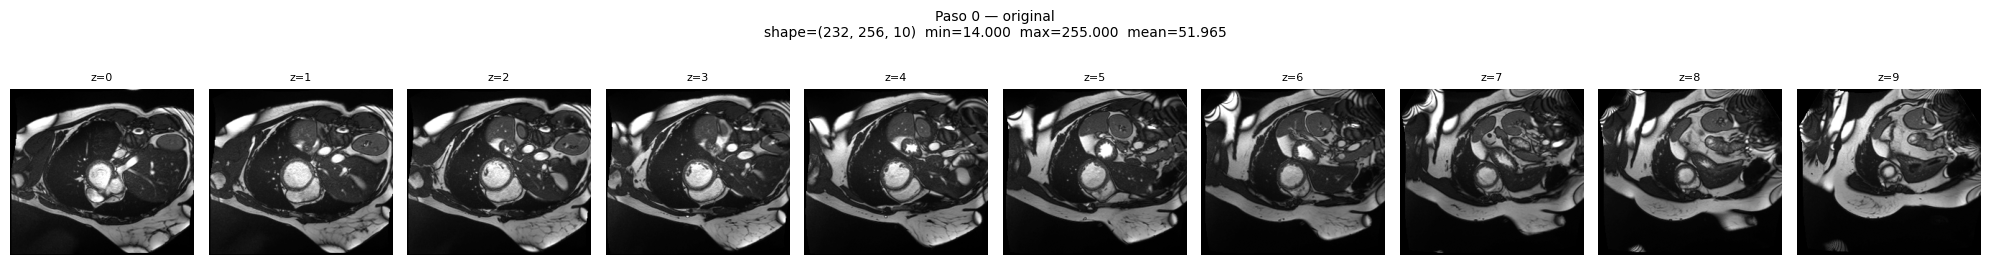

In [4]:
img  = nib.load(PATH)
data = np.asarray(img.dataobj, dtype=np.float32)
if data.ndim == 3:
    data = data[..., np.newaxis]

dx, dy, dz = [float(img.header.get_zooms()[i]) for i in range(3)]
_, _, _, T  = data.shape

print(f'Shape 4D: {data.shape}   (H, W, Z, T)')
print(f'Zooms:    dx={dx:.3f} mm  dy={dy:.3f} mm  dz={dz:.3f} mm')

step0 = data[:, :, :, T_IDX].copy()
print(f'Frame t={T_IDX}: shape={step0.shape}  min={step0.min():.1f}  max={step0.max():.1f}')
show_volume(step0, 'Paso 0 — original', norm_per_slice=True)

---
## Paso 1 - Resampleo a spacing fijo (1.5 mm, 1.5 mm, 10 mm)

Escalas:  x=1.094  y=1.094  z=1.000
Shape: (232, 256, 10) → (254, 280, 10)


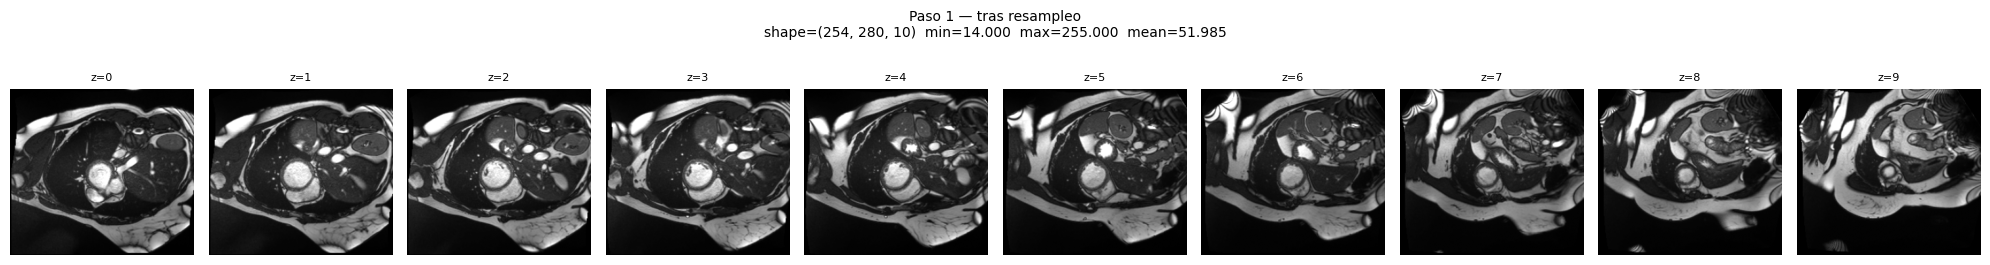

In [5]:
scale_x = dx / INPLANE_SPACING_MM
scale_y = dy / INPLANE_SPACING_MM
scale_z = dz / TARGET_DZ_MM

print(f'Escalas:  x={scale_x:.3f}  y={scale_y:.3f}  z={scale_z:.3f}')
step1 = zoom(step0, (scale_x, scale_y, scale_z), order=1)
print(f'Shape: {step0.shape} -> {step1.shape}')
show_volume(step1, 'Paso 1 - tras resampleo', norm_per_slice=True)

---
## Paso 2 - Clip p1-p99 -> [0, 1]
Se hace ANTES del padding. El fondo real queda en ≈0.

p1=15.000  p99=165.266
Rango: min=0.000  max=1.000


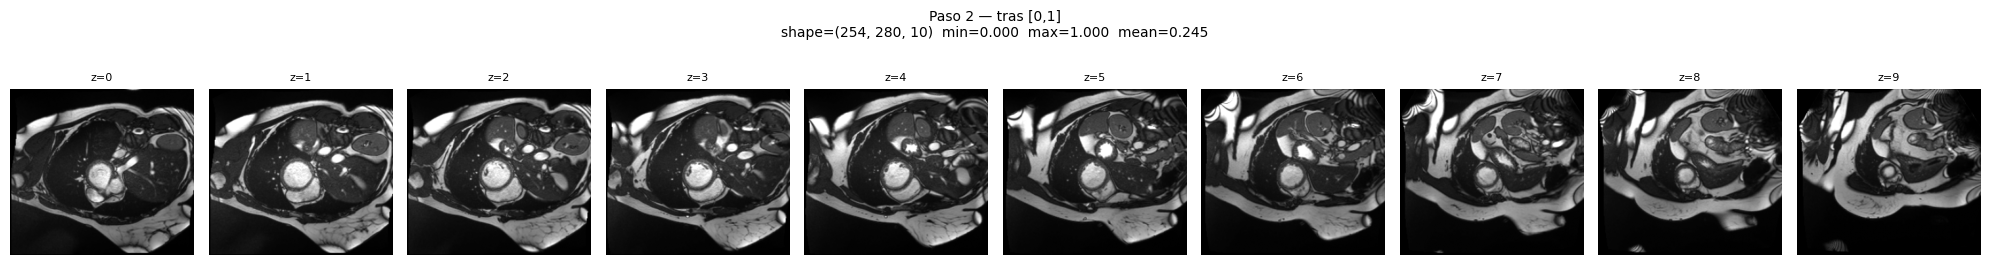

In [6]:
p1, p99 = np.percentile(step1, [1, 99])
clipped  = np.clip(step1, p1, p99)
step2    = (clipped - p1) / max(p99 - p1, 1e-8)

print(f'p1={p1:.3f}  p99={p99:.3f}')
print(f'Rango: min={step2.min():.3f}  max={step2.max():.3f}')
show_volume(step2, 'Paso 2 — tras [0,1]')

---
## Paso 3 - Crop/pad a (224, 224, 10)
Padding con ceros. Como el fondo ya es ≈0, el padding coincide con el fondo.

D original: 10  ->  target: 10
Z sin cambio
Shape: (224, 224, 10)


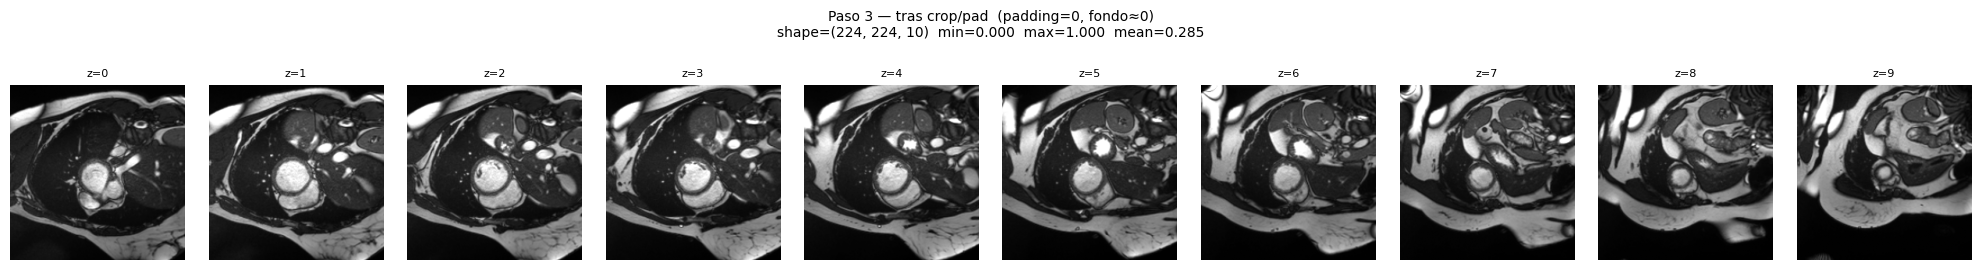

In [12]:
D = step2.shape[2]
t = torch.from_numpy(step2[np.newaxis].astype(np.float32))

print(f'D original: {D}  ->  target: {TARGET_D}')
if D > TARGET_D:
    start = (D - TARGET_D) // 2
    t = t[:, :, :, start : start + TARGET_D]
    print(f'Z crop: start={start}')
elif D < TARGET_D:
    pad_b = (TARGET_D - D) // 2
    pad_a = TARGET_D - D - pad_b
    t = torch.nn.functional.pad(t, (pad_b, pad_a))
    print(f'Z pad: antes={pad_b}  después={pad_a}  (ceros = fondo ≈ 0)')
else:
    print('Z sin cambio')

t = CenterSpatialCrop(roi_size=(TARGET_H, TARGET_W, TARGET_D))(t)
t = SpatialPad(spatial_size=(TARGET_H, TARGET_W, TARGET_D))(t)

step3 = t.numpy()[0]
print(f'Shape: {step3.shape}')
show_volume(step3, 'Paso 3 — tras crop/pad  (padding=0, fondo≈0)')

---
## Paso 4 - Z-score
Fondo y padding son ambos ≈0 antes de este paso -> quedan en el mismo valor negativo `-μ/σ`.

μ=0.2854  σ=0.2434
Rango: min=-1.173  max=2.936
Fondo/padding (0 tras paso 3) → -1.1727


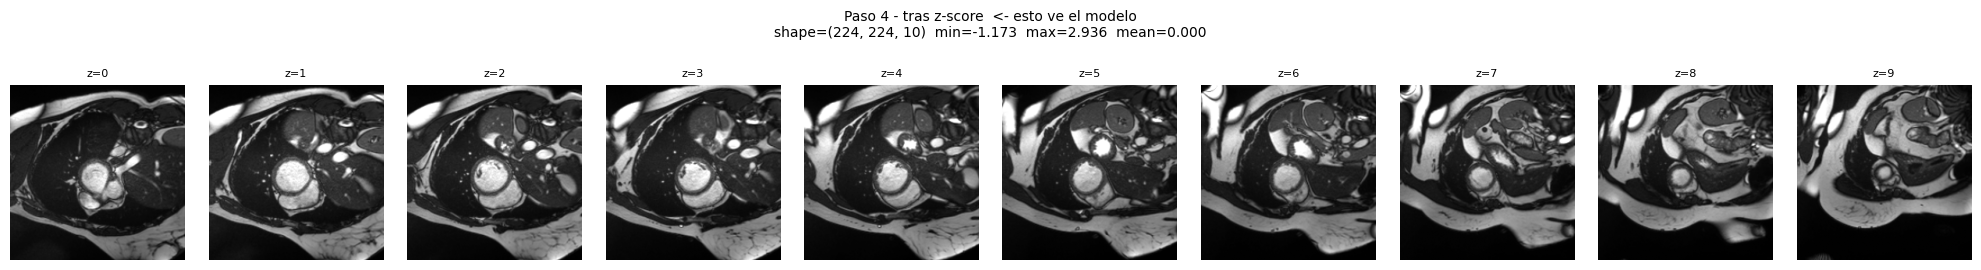

In [13]:
mu, sigma = step3.mean(), step3.std()
if sigma < 1e-8: sigma = 1e-8
step4 = (step3 - mu) / sigma

print(f'μ={mu:.4f}  σ={sigma:.4f}')
print(f'Rango: min={step4.min():.3f}  max={step4.max():.3f}')
print(f'Fondo/padding (0 tras paso 3) → {-mu/sigma:.4f}')
show_volume(step4, 'Paso 4 - tras z-score  <- esto ve el modelo')